In [1]:
import requests
import pandas as pd
import os
import matplotlib.pyplot as plt

START_DATE = '2019-01-01'
END_DATE   = '2024-12-31'
OUTPUT     = '../../data/raw/weather_hourly.csv'

STATIONS = {
    'Sacramento':  (38.58, -121.49),
    'San Jose':    (37.34, -121.89),
    'Fresno':      (36.74, -119.79),
    'Los Angeles': (34.05, -118.24),
}

VARIABLES = [
    'temperature_2m',
    'precipitation',
    'shortwave_radiation',
    'windspeed_10m',
    'relativehumidity_2m',
]

In [2]:
def fetch_station(name, lat, lon):
    print(f'Fetching {name} ({lat}, {lon})...')
    r = requests.get(
        'https://archive-api.open-meteo.com/v1/archive',
        params={
            'latitude':        lat,
            'longitude':       lon,
            'start_date':      START_DATE,
            'end_date':        END_DATE,
            'hourly':          ','.join(VARIABLES),
            'timezone':        'America/Los_Angeles',
            'wind_speed_unit': 'ms',
        },
        timeout=60
    )
    r.raise_for_status()
    df = pd.DataFrame(r.json()['hourly'])
    df['time'] = pd.to_datetime(df['time'])
    df = df.set_index('time')
    return df


frames = {name: fetch_station(name, lat, lon) for name, (lat, lon) in STATIONS.items()}

Fetching Sacramento (38.58, -121.49)...
Fetching San Jose (37.34, -121.89)...
Fetching Fresno (36.74, -119.79)...
Fetching Los Angeles (34.05, -118.24)...


In [3]:
weather = pd.concat(frames.values()).groupby(level=0)[VARIABLES].mean()
weather.index.name = 'datetime'
weather = weather.rename(columns={
    'temperature_2m':     'temperature_c',
    'precipitation':      'precipitation_mm',
    'shortwave_radiation': 'solar_radiation_wm2',
    'windspeed_10m':       'windspeed_ms',
    'relativehumidity_2m': 'humidity_pct',
})

os.makedirs(os.path.dirname(OUTPUT), exist_ok=True)
weather.to_csv(OUTPUT)
print(f'Saved {len(weather):,} rows → {OUTPUT}')
weather.head()

Saved 52,608 rows → ../../data/raw/weather_hourly.csv


,temperature_c,precipitation_mm,solar_radiation_wm2,windspeed_ms,humidity_pct
datetime,,,,,
2019-01-01 00:00:00,4.525,0.0,0.0,3.6525,57.50
2019-01-01 01:00:00,4.475,0.0,0.0,3.1250,56.50
2019-01-01 02:00:00,3.475,0.0,0.0,3.1950,57.25
2019-01-01 03:00:00,3.500,0.0,0.0,2.6350,54.00
2019-01-01 04:00:00,2.025,0.0,0.0,2.9850,59.50


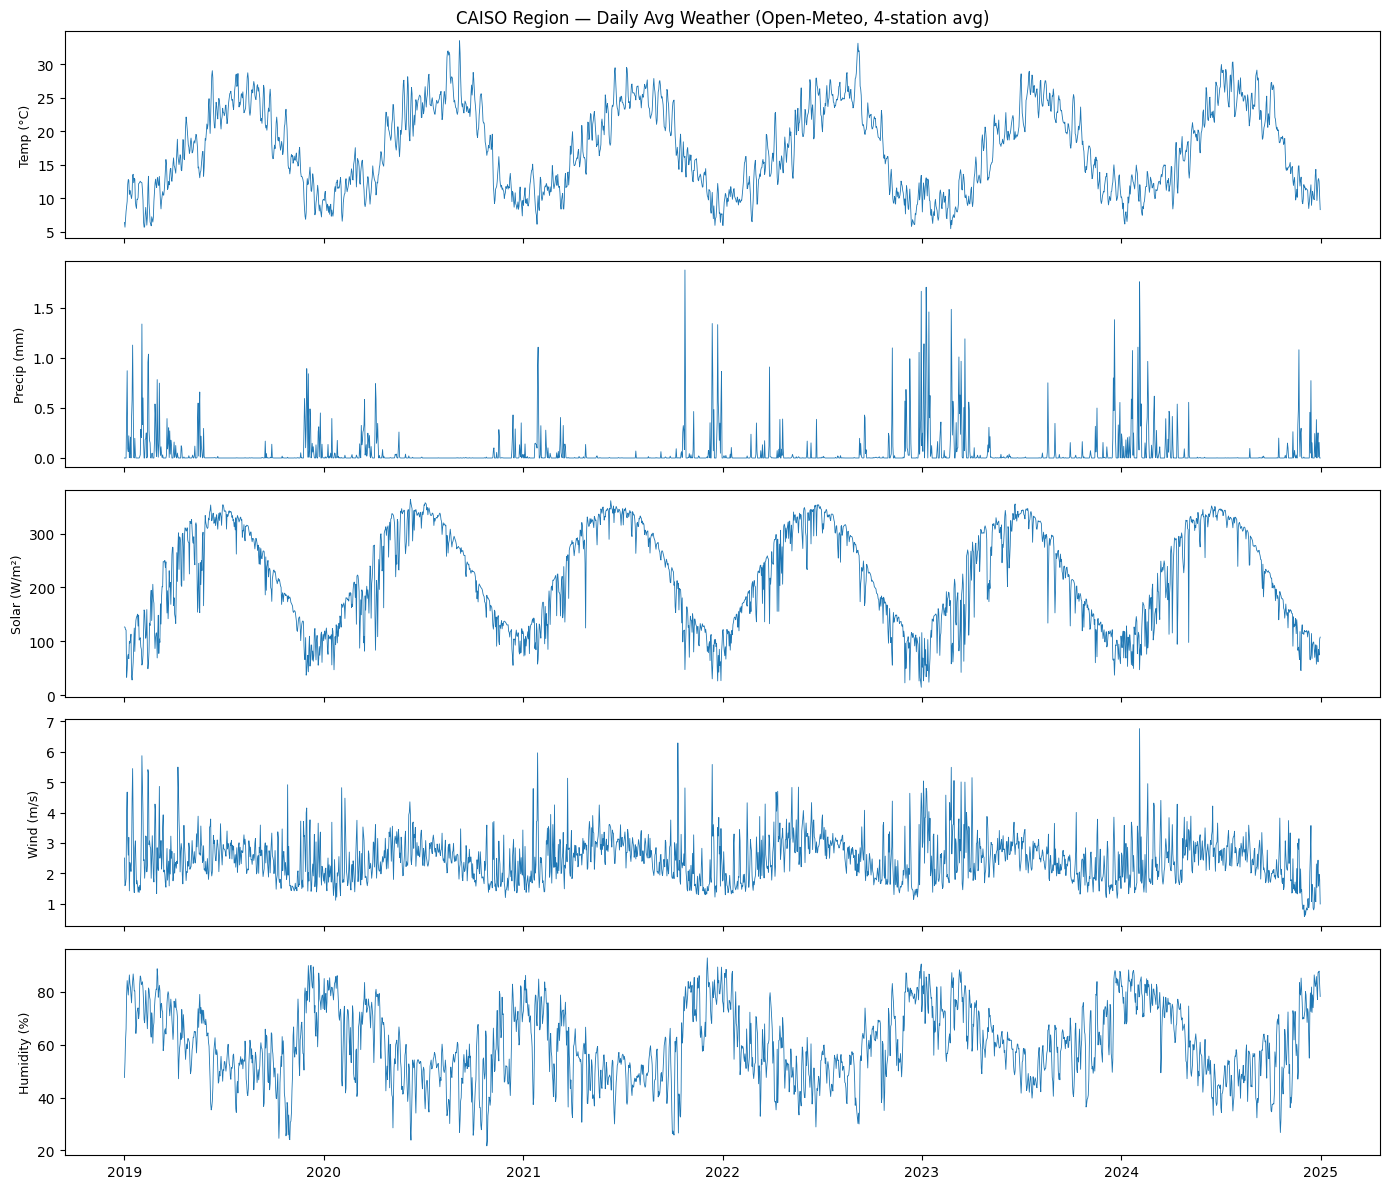

In [4]:
daily = weather.resample('D').mean()
cols   = ['temperature_c', 'precipitation_mm', 'solar_radiation_wm2', 'windspeed_ms', 'humidity_pct']
labels = ['Temp (°C)', 'Precip (mm)', 'Solar (W/m²)', 'Wind (m/s)', 'Humidity (%)']

fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
for ax, col, label in zip(axes, cols, labels):
    ax.plot(daily.index, daily[col], linewidth=0.6)
    ax.set_ylabel(label, fontsize=9)

axes[0].set_title('CAISO Region — Daily Avg Weather (Open-Meteo, 4-station avg)')
plt.tight_layout()
plt.show()